<a href="https://colab.research.google.com/github/kolithawarnakulasooriya/Gen-AI-Torch-Learning/blob/databricks/data-dists.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# multiple regression

import pandas as pd

file = 'http://cdn.sundog-soft.com/Udemy/DataScience/cars.xls'

df = pd.read_excel(file)
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [2]:
# filter data
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

x = df[['Mileage','Cylinder']]
y = df[['Price']]

print(x)

x = scale.fit_transform(x)
x[:5]


     Mileage  Cylinder
0       8221         6
1       9135         6
2      13196         6
3      16342         6
4      19832         6
..       ...       ...
799    16229         6
800    19095         6
801    20484         6
802    25979         6
803    35662         6

[804 rows x 2 columns]


array([[-1.41748516e+00,  5.27410473e-01],
       [-1.30590228e+00,  5.27410473e-01],
       [-8.10127593e-01,  5.27410473e-01],
       [-4.26057864e-01,  5.27410473e-01],
       [ 8.04768895e-06,  5.27410473e-01]])

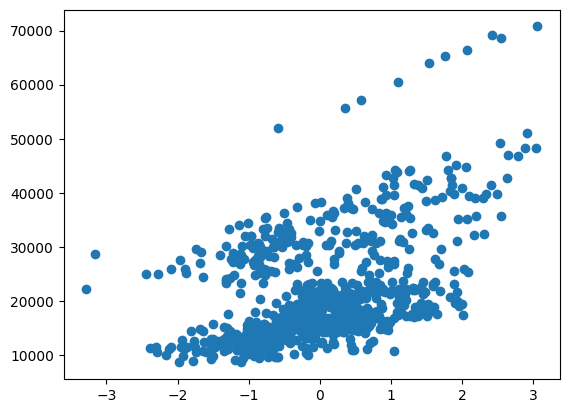

In [3]:
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA

ca = PCA(n_components=1)
x_pca = ca.fit_transform(x)
plt.scatter(x_pca, y)
plt.show()

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

sm = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = sm.fit(x_train, y_train)
print(model.coef_)
model.score(x_test, y_test)

[[-1031.73179092  5177.95019346]]


0.4333599923078163

In [6]:
import numpy as np

p = scale.transform([[7000, 6]])

model.predict(p)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[25602.15729574]])

## Validate Train and Test data
## K Fold Cross Validation

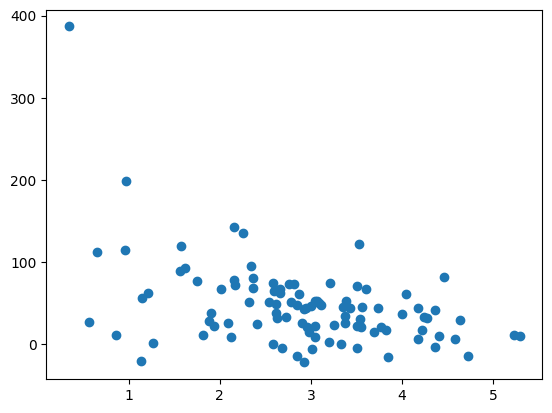

In [17]:
np.random.seed(2)

x = np.random.normal(3, 1, 100)
y = np.random.normal(100, 80, 100) / x
plt.scatter(x, y)

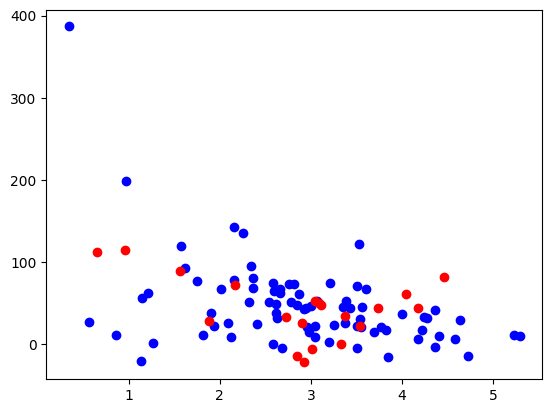

In [29]:
 split_half = 0.2
 x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=split_half)

 plt.scatter(x_train, y_train, color='blue')
 plt.scatter(x_test, y_test, color='red')

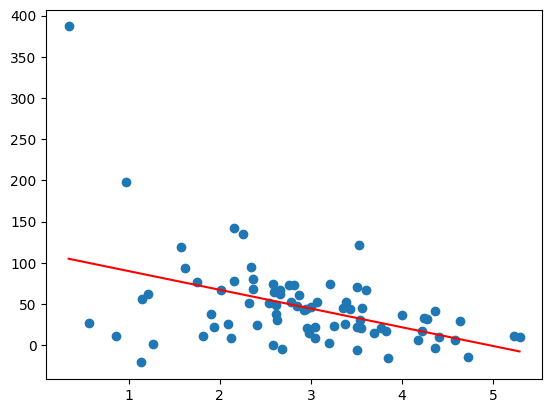

In [38]:
x_train = np.array(x_train)
y_train = np.array(y_train)

m, b = np.polyfit(x_train, y_train, 1)

plt.scatter(x_train, y_train)

x_line = np.linspace(min(x_train), max(x_train), int(100 * (1-split_half)))
y_line = m * x_line + b

plt.plot(x_line, y_line, color='red')

In [39]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True)
kf.get_n_splits(x)

print(kf)

for train_index, test_index in kf.split(x):
    print("TRAIN:", train_index, "TEST:", test_index)

KFold(n_splits=5, random_state=None, shuffle=True)
TRAIN: [ 2  3  4  5  6  7  8  9 10 11 12 13 14 16 17 18 19 21 22 23 24 26 28 29
 30 31 32 33 34 35 36 37 38 39 40 41 42 43 45 48 49 50 51 52 53 54 58 59
 61 62 63 64 65 66 67 68 69 72 73 74 75 76 77 78 79 80 81 84 85 86 87 89
 90 91 92 94 95 96 97 99] TEST: [ 0  1 15 20 25 27 44 46 47 55 56 57 60 70 71 82 83 88 93 98]
TRAIN: [ 0  1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 23 24 25 27
 28 29 30 32 33 34 36 38 40 41 42 43 44 45 46 47 48 49 50 51 52 54 55 56
 57 58 60 61 62 63 64 65 68 69 70 71 72 74 76 77 78 81 82 83 85 86 88 89
 90 92 93 94 95 96 97 98] TEST: [ 4 21 22 26 31 35 37 39 53 59 66 67 73 75 79 80 84 87 91 99]
TRAIN: [ 0  1  2  3  4  5  6  7  9 12 13 15 20 21 22 24 25 26 27 29 31 33 35 36
 37 38 39 40 41 43 44 45 46 47 48 50 51 52 53 55 56 57 58 59 60 61 62 63
 64 65 66 67 69 70 71 72 73 75 76 77 79 80 81 82 83 84 85 86 87 88 89 91
 92 93 94 95 96 97 98 99] TEST: [ 8 10 11 14 16 17 18 19 23 28 30 32 34 42 49 54 68